<a href="https://colab.research.google.com/github/Walbyq/beer-sales-timeseries-forecast/blob/main/beer_sales_timeseries.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Установка библиотек

In [344]:
# !pip install pmdarima
# !pip install numpy==1.26.4

# Импорт библиотек

In [345]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pmdarima import auto_arima
import statsmodels.api as sm
import statsmodels.tsa.api as smt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

from datetime import datetime, timedelta
from tabulate import tabulate

# Загрузка файлов

In [346]:
# Подключение к Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [347]:
import os
path = '/content/drive/MyDrive/data/data_for_test_arch'

# Просмотр файлов в папке
files = os.listdir(path)
print(files)

['beer_sales_data.parquet', 'ana_sales_data.parquet', 'cig_sales_data.parquet', 'demographic_data.parquet', 'cig_upc.parquet', 'ana_upc.parquet', 'beer_upc.parquet']


Для анализа возьмем набор данных о продажах пива

In [348]:
# Загрузка данных
df = pd.read_parquet(f"{path}/beer_sales_data.parquet")
upc_df = pd.read_parquet(f"{path}/beer_upc.parquet", columns=['upc', 'descrip'])

# Анализ данных

In [349]:
# Функция для красивого отображения датафреймов
def tabulate_df(df):
    return print(tabulate(df, headers='keys', tablefmt='psql'))

# Вывод информации о датафрейме
print("="*20, "Данные о продажах пива:", "="*20)
tabulate_df(df.head())
tabulate_df(upc_df.head())
print("\nРазмерность:", df.shape)
print("\nПустые значения:")
print(df.isnull().sum())
print("\nСтатистическое описание:")
print(tabulate_df(df.describe()))
print("\nОсновная информация:")
print(df.info())

==================== Данные о продажах пива: ====================
+----+---------+-------+--------+--------+-------+---------+--------+
|    |   store |   upc |   week |   move |   qty |   price | sale   |
|----+---------+-------+--------+--------+-------+---------+--------|
|  0 |       2 |   294 |    298 |     11 |     1 |    2.62 |        |
|  1 |       2 |   294 |    299 |      9 |     1 |    2.51 |        |
|  2 |       2 |   294 |    300 |      6 |     1 |    2.49 |        |
|  3 |       2 |   294 |    301 |      5 |     1 |    2.99 |        |
|  4 |       2 |   294 |    302 |      1 |     1 |    2.49 |        |
+----+---------+-------+--------+--------+-------+---------+--------+
+----+-------+----------------------+
|    |   upc | descrip              |
|----+-------+----------------------|
|  0 |   294 | BEER LIMIT           |
|  1 |   307 | HEINEKEN KINGSIZE CA |
|  2 |   710 | BUDWEISER BEER       |
|  3 |   711 | BUDWEISER DRY BEER   |
|  4 |   712 | BUDWEISER LIGHT BEER |


Удалим ненужные строки, в которых не было продаж

In [350]:
df = df[df['move'] != 0]

Столбец *sale* содержит пустые значения, исправим это, заменив пустые строки на 0, если товар был преобретен без скидки и на 1, если товар был со скидкой. Также удалим недели с нулевыми продажами

In [351]:
df['sale'] = df['sale'].apply(lambda x: False if x is None else True)

Из статистического описания таблицы *beer_sales_data* мы видим, что в ней присутствуют значения *qty* = 2 (кол-во предметов, упакованных вместе). Рассмотрим эти значения:

In [352]:
# Фильтрация по количеству 'qty' равному 2
print("Продажи с параметром 'qty' = 2:")
filtered_qty = df[df['qty'] == 2]
print(tabulate_df(filtered_qty.head()))

# Фильтрация по UPC
print("\nПрочие продажи одного из перечисленных товаров:")
filtered_upc = df[df['upc'] == 8797502650]
print(tabulate_df(filtered_upc.head()))

Продажи с параметром 'qty' = 2:
+---------+---------+------------+--------+--------+-------+---------+--------+
|         |   store |        upc |   week |   move |   qty |   price | sale   |
|---------+---------+------------+--------+--------+-------+---------+--------|
|  980319 |      95 | 3410015505 |    140 |    142 |     2 |       5 | True   |
| 1083765 |      95 | 3410017505 |    140 |    769 |     2 |       5 | True   |
| 1342399 |      95 | 3410057505 |    140 |    578 |     2 |       5 | False  |
| 3776134 |      14 | 8797502650 |    151 |      1 |     2 |       3 | True   |
| 3776135 |      14 | 8797502650 |    152 |     13 |     2 |       3 | False  |
+---------+---------+------------+--------+--------+-------+---------+--------+
None

Прочие продажи одного из перечисленных товаров:
+---------+---------+------------+--------+--------+-------+---------+--------+
|         |   store |        upc |   week |   move |   qty |   price | sale   |
|---------+---------+------------+

Видим, что цена на них выше, чем при *qty* = 1, даже при условии, что они преобретены по скидке. Делаем вывод, что цена указана не за единицу товара, а за упаковку. Приведем все значения к *qty* = 1:

In [353]:
# Меняем количество проданного товара и цену
df['move'] = df['move'] * df['qty']
df['price'] = df['price'] / df['qty']

In [354]:
# Удаляем ненужные столбцы
df = df.drop(columns=['qty','store', 'upc'])
tabulate_df(df.head())

+----+--------+--------+---------+--------+
|    |   week |   move |   price | sale   |
|----+--------+--------+---------+--------|
|  0 |    298 |     11 |    2.62 | False  |
|  1 |    299 |      9 |    2.51 | False  |
|  2 |    300 |      6 |    2.49 | False  |
|  3 |    301 |      5 |    2.99 | False  |
|  4 |    302 |      1 |    2.49 | False  |
+----+--------+--------+---------+--------+


Каждому порядковому номеру недели поставим в соответствие дату. Даты возьмем из мануала https://www.chicagobooth.edu/research/kilts/research-data/-/media/enterprise/centers/kilts/datasets/dominicks-dataset/dominicks-manual-and-codebook_kiltscenter

In [355]:
# Начальная дата первой недели
start_date = datetime.strptime('09/14/1989', '%m/%d/%Y')

# Функция для получения даты начала недели
def get_start_date_of_week(week_num):
    return start_date + timedelta(weeks=week_num - 1)

# Добавляем дату
df['date'] = df['week'].apply(get_start_date_of_week)

print("Объем продаж пива в неделю, начиная с указанной даты:")
tabulate_df(df.head())

Объем продаж пива в неделю, начиная с указанной даты:
+----+--------+--------+---------+--------+---------------------+
|    |   week |   move |   price | sale   | date                |
|----+--------+--------+---------+--------+---------------------|
|  0 |    298 |     11 |    2.62 | False  | 1995-05-25 00:00:00 |
|  1 |    299 |      9 |    2.51 | False  | 1995-06-01 00:00:00 |
|  2 |    300 |      6 |    2.49 | False  | 1995-06-08 00:00:00 |
|  3 |    301 |      5 |    2.99 | False  | 1995-06-15 00:00:00 |
|  4 |    302 |      1 |    2.49 | False  | 1995-06-22 00:00:00 |
+----+--------+--------+---------+--------+---------------------+


Агрегируем данные по параметрам

In [356]:
# Задаем недели праздников
holiday_dates = {
    '4th of July': [95, 147, 199, 251, 303, 356],
    'Labor Day': [103, 156, 208, 260, 312, 364],
    'Halloween': [112, 164, 216, 268, 320, 372],
    'Thanksgiving': [116, 168, 220, 272, 324, 377],
    'Christmas': [119, 172, 224, 276, 328, 380],
    'New Year': [120, 173, 225, 277, 329, 381],
    'Presidents Day': [128, 180, 232, 284, 336, 389],
    'Easter': [133, 185, 238, 289, 341, 393],
    'Memorial Day': [141, 194, 256, 298, 350],
}

# Функция определения сезона на основе месяца
def get_season(month):
    if month in [12, 1, 2]: return 'Winter'
    elif month in [3, 4, 5]: return 'Spring'
    elif month in [6, 7, 8]: return 'Summer'
    else: return 'Autumn'

# Функция для определения праздника или обычного дня
def get_holiday(week):
    for holiday_name, weeks in holiday_dates.items():
        if week in weeks: return holiday_name
    return 'Ordinary'

# Функция для агрегации по различным параметрам
def aggregate_sales(df, col):
    # Агрегация по заданному столбцу
    sales = df.groupby(col)['move'].sum().reset_index()
    count = df.groupby(col)['date'].count().reset_index(name='count')

    # Объединение данных
    aggregated = sales.merge(count, on=col)

    # Расчет средней продажи
    aggregated['avg_move'] = aggregated['move'] / aggregated['count']

    return aggregated

# Добавление столбцов недели и праздника
df['season'] = df['date'].dt.month.apply(get_season)
df['holiday'] = df['week'].apply(get_holiday)

# Агрегация
price_sales = aggregate_sales(df, 'price')
sale_sales = aggregate_sales(df, 'sale')
season_sales = aggregate_sales(df, 'season')
holiday_sales = aggregate_sales(df, 'holiday')

# Вывод результатов
print("Агрегация по цене:")
tabulate_df(price_sales.head())
print("\nАгрегация по скидке:")
tabulate_df(sale_sales.head())
print("\nАгрегация по сезону:")
tabulate_df(season_sales.head())
print("\nАгрегация по празднику:")
tabulate_df(holiday_sales.head(20))

Агрегация по цене:
+----+---------+--------+---------+------------+
|    |   price |   move |   count |   avg_move |
|----+---------+--------+---------+------------|
|  0 |    0.01 |      1 |       1 |     1      |
|  1 |    0.79 |     50 |       2 |    25      |
|  2 |    0.92 |      7 |       1 |     7      |
|  3 |    0.95 |     10 |       1 |    10      |
|  4 |    0.99 |  27348 |     458 |    59.7118 |
+----+---------+--------+---------+------------+

Агрегация по скидке:
+----+--------+---------+---------+------------+
|    | sale   |    move |   count |   avg_move |
|----+--------+---------+---------+------------|
|  0 | False  | 7284594 | 1421392 |    5.12497 |
|  1 | True   | 6143458 |  544756 |   11.2774  |
+----+--------+---------+---------+------------+

Агрегация по сезону:
+----+----------+---------+---------+------------+
|    | season   |    move |   count |   avg_move |
|----+----------+---------+---------+------------|
|  0 | Autumn   | 2975497 |  460938 |    6.45531 

Построим графики распределения

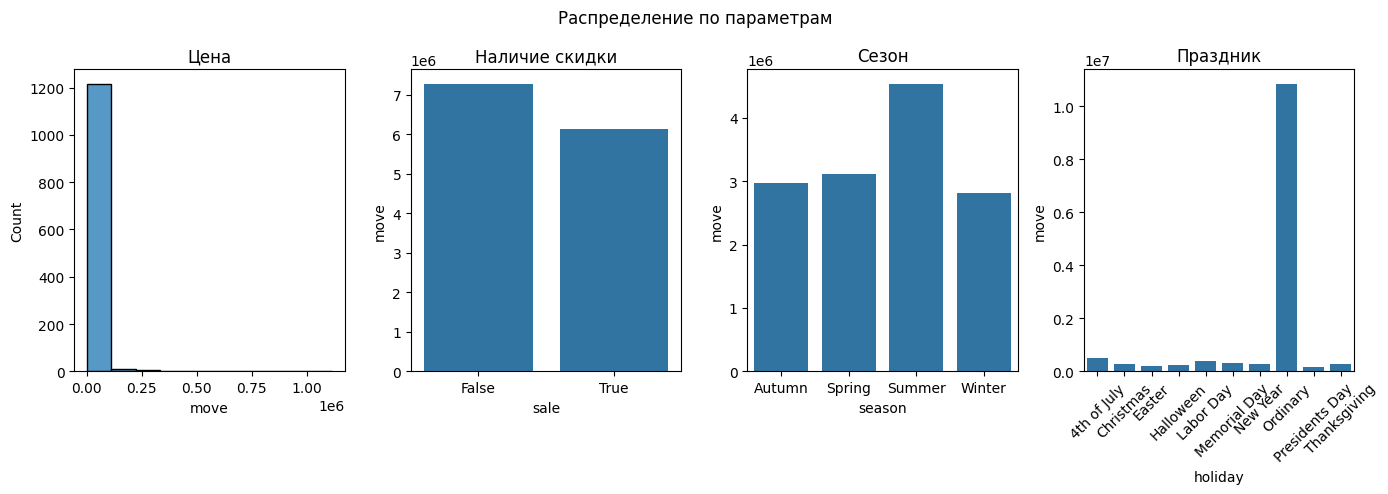

In [357]:
fig, axes = plt.subplots(1, 4, figsize=(14, 5))
plt.suptitle('Распределение по параметрам')

# Гистограмма средних продаж по цене
sns.histplot(price_sales['move'], bins=10, ax=axes[0])
axes[0].set_title('Цена')

# График средних продаж по наличию скидки
sns.barplot(x='sale', y='move', data=sale_sales, ax=axes[1])
axes[1].set_title('Наличие скидки')

# График средних продаж по сезонам
sns.barplot(x='season', y='move', data=season_sales, ax=axes[2])
axes[2].set_title('Сезон')

# График средних продаж по сезонам
sns.barplot(x='holiday', y='move', data=holiday_sales, ax=axes[3])
axes[3].set_title('Праздник')
# Поворот подписей
axes[3].set_xticks(range(len(holiday_sales['holiday'])))
axes[3].set_xticklabels(axes[3].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

Проанализируем зависимость спроса от цены, скидки, сезона и праздника

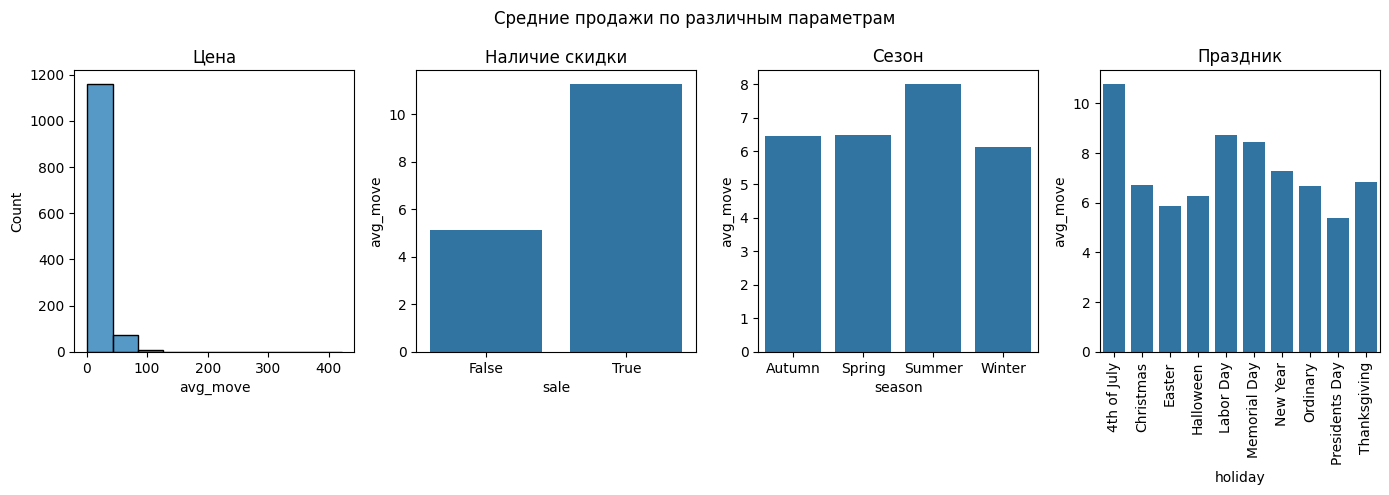

In [358]:
fig, axes = plt.subplots(1, 4, figsize=(14, 5))
plt.suptitle('Средние продажи по различным параметрам')

# Гистограмма средних продаж по цене
sns.histplot(price_sales['avg_move'], bins=10, ax=axes[0])
axes[0].set_title('Цена')

# График средних продаж по наличию скидки
sns.barplot(x='sale', y='avg_move', data=sale_sales, ax=axes[1])
axes[1].set_title('Наличие скидки')

# График средних продаж по сезонам
sns.barplot(x='season', y='avg_move', data=season_sales, ax=axes[2])
axes[2].set_title('Сезон')

# График средних продаж по сезонам
sns.barplot(x='holiday', y='avg_move', data=holiday_sales, ax=axes[3])
axes[3].set_title('Праздник')

# Поворот подписей
axes[3].set_xticks(range(len(holiday_sales['holiday'])))
axes[3].set_xticklabels(axes[3].get_xticklabels(), rotation=90)

plt.tight_layout()
plt.show()

По графикам видно:
- При увеличении цены спрос падает
- Сниженная цена значительно привлекает покупателей
- В теплые сезоны люди хотят пить больше пива
- Спрос значительно увеличивается на День Независимости, немного на День Труда и День Памяти, а в остальные праздники не сильно отклоняется от продаж в обычные дни

In [359]:
tabulate_df(df.head())
print("Строк: ", df.shape[0])

+----+--------+--------+---------+--------+---------------------+----------+--------------+
|    |   week |   move |   price | sale   | date                | season   | holiday      |
|----+--------+--------+---------+--------+---------------------+----------+--------------|
|  0 |    298 |     11 |    2.62 | False  | 1995-05-25 00:00:00 | Spring   | Memorial Day |
|  1 |    299 |      9 |    2.51 | False  | 1995-06-01 00:00:00 | Summer   | Ordinary     |
|  2 |    300 |      6 |    2.49 | False  | 1995-06-08 00:00:00 | Summer   | Ordinary     |
|  3 |    301 |      5 |    2.99 | False  | 1995-06-15 00:00:00 | Summer   | Ordinary     |
|  4 |    302 |      1 |    2.49 | False  | 1995-06-22 00:00:00 | Summer   | Ordinary     |
+----+--------+--------+---------+--------+---------------------+----------+--------------+
Строк:  1966148


In [360]:
# Агрегирование данных
df = df.groupby('date').agg({
    'move': 'sum',
    'price': 'mean',
    'sale': 'mean',
    'season': 'first',
    'holiday': 'first',
    'week': 'first'
}).reset_index()

tabulate_df(df.head())
print("Строк: ", df.shape[0])

+----+---------------------+--------+---------+----------+----------+-------------+--------+
|    | date                |   move |   price |     sale | season   | holiday     |   week |
|----+---------------------+--------+---------+----------+----------+-------------+--------|
|  0 | 1991-06-06 00:00:00 |  58515 | 5.31675 | 0.185256 | Summer   | Ordinary    |     91 |
|  1 | 1991-06-13 00:00:00 |  70570 | 5.30955 | 0.18493  | Summer   | Ordinary    |     92 |
|  2 | 1991-06-20 00:00:00 |  69579 | 5.20263 | 0.258914 | Summer   | Ordinary    |     93 |
|  3 | 1991-06-27 00:00:00 |  70108 | 5.04007 | 0.196081 | Summer   | Ordinary    |     94 |
|  4 | 1991-07-04 00:00:00 | 100298 | 5.13956 | 0.174063 | Summer   | 4th of July |     95 |
+----+---------------------+--------+---------+----------+----------+-------------+--------+
Строк:  302


Восполним недостающие даты

In [361]:
# Определяем минимальное и максимальное значение даты
min_date = df['date'].min()
max_date = df['date'].max()

# Создаем полный диапазон дат от min до max с шагом в неделю
full_range = pd.date_range(start=min_date, end=max_date, freq='W-Thu').to_frame(index=False, name='date')

# Объединяем с оригинальным датафреймом
df = full_range.merge(df, on='date', how='left')

# Заполняем пропуски
df['move'] = df['move'].fillna(df['move'].mean())
df['price'] = df['price'].fillna(df['price'].mean())
df['sale'] = df['sale'].fillna(df['sale'].mean())
df['season'] = df['season'].fillna(df['date'].dt.month.apply(get_season))
df['holiday'] = df['holiday'].fillna(df['week'].apply(get_holiday))

# Удаляем столбец 'week'
df = df.drop(columns=['week'])

tabulate_df(df.head())
print("Строк после добавления пропущенных дат: ", df.shape[0])

+----+---------------------+--------+---------+----------+----------+-------------+
|    | date                |   move |   price |     sale | season   | holiday     |
|----+---------------------+--------+---------+----------+----------+-------------|
|  0 | 1991-06-06 00:00:00 |  58515 | 5.31675 | 0.185256 | Summer   | Ordinary    |
|  1 | 1991-06-13 00:00:00 |  70570 | 5.30955 | 0.18493  | Summer   | Ordinary    |
|  2 | 1991-06-20 00:00:00 |  69579 | 5.20263 | 0.258914 | Summer   | Ordinary    |
|  3 | 1991-06-27 00:00:00 |  70108 | 5.04007 | 0.196081 | Summer   | Ordinary    |
|  4 | 1991-07-04 00:00:00 | 100298 | 5.13956 | 0.174063 | Summer   | 4th of July |
+----+---------------------+--------+---------+----------+----------+-------------+
Строк после добавления пропущенных дат:  309


Создадим функцию для подсчета средней абсолютной процентной ошибки:

In [362]:
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Предобработка данных

Выполним нормализацию и категориализацию данных

In [363]:
# Нормализация числовых переменных
scaler = MinMaxScaler()
df[['price', 'sale']] = scaler.fit_transform(df[['price', 'sale']])

# One-hot encoding категориальных переменных
df = pd.get_dummies(df, columns=['season', 'holiday'], drop_first=True)

tabulate_df(df.head())

+----+---------------------+--------+-----------+----------+-----------------+-----------------+-----------------+---------------------+------------------+---------------------+---------------------+------------------------+--------------------+--------------------+--------------------------+------------------------+
|    | date                |   move |     price |     sale | season_Spring   | season_Summer   | season_Winter   | holiday_Christmas   | holiday_Easter   | holiday_Halloween   | holiday_Labor Day   | holiday_Memorial Day   | holiday_New Year   | holiday_Ordinary   | holiday_Presidents Day   | holiday_Thanksgiving   |
|----+---------------------+--------+-----------+----------+-----------------+-----------------+-----------------+---------------------+------------------+---------------------+---------------------+------------------------+--------------------+--------------------+--------------------------+------------------------|
|  0 | 1991-06-06 00:00:00 |  58515 | 0.207

# Вспомогательные функции

Напишем функцию для визуализации 2 графиков:

1.   Реальный и предсказанный временной ряд на тестовой выборке
2.   Прогноз продаж на год вперед

In [400]:
def show_results(df, results, exog, forecast_periods=52, X_test=None, y_test=None, is_ts_model=False):
    """
    Визуализация результатов обучения и прогноза.

    Параметры:
    - df: DataFrame с историческими данными (индекс — даты или номера).
    - target_var: название целевой переменной (строка).
    - results: обученная модель или объект с методами predict/get_forecast.
    - exog: независимые переменные для предсказания
    - forecast_periods: количество периодов для прогноза (int), если None — прогноз не строится.
    - X_test, y_test: тестовые данные для оценки модели (только для не временных моделей).
    - is_ts_model: флаг, указывающий, что модель — временной ряд.
    """
    plt.figure(figsize=(16, 10))

    # --- Сабплот 1: Реальные и предсказанные на тесте значения ---
    plt.subplot(2, 1, 1)
    plt.plot(df.index, df['move'], label="Реальное")

    if is_ts_model:
        predictions = results.predict(start=df.index[0], end=df.index[-1])
        error = mean_absolute_percentage_error(df['move'], predictions)
        plt.plot(predictions.index, predictions, label=f"Предсказанное (MAPE: {error:.2f}%)", color='orange')
    else:
        if X_test is None or y_test is None:
            raise ValueError("Для не временной модели необходимо передать X_test и y_test")
        predictions = results.predict(X_test)
        error = mean_absolute_percentage_error(y_test, predictions)
        plt.scatter(df.index[X_test.index], predictions, label=f"Предсказанное (MAPE: {error:.2f}%)", color='orange')

    plt.title("Реальный и предсказанный временной ряд")
    plt.xlabel("Дата")
    plt.ylabel("Продажи ")
    plt.legend()
    plt.grid()

    # --- Сабплот 2: Прогноз ---
    plt.subplot(2, 1, 2)
    plt.plot(df.index, df['move'], label="Исторические данные")

    last_index = df.index[-1]

    # Создаем exog для прогноза
    if is_ts_model:
        forecast_steps = results.get_forecast(steps=forecast_periods, exog=exog)
        forecast = forecast_steps.predicted_mean
        conf_int = forecast_steps.conf_int()

        # Создаем индекс для прогноза
        forecast_index = pd.date_range(start=last_index + pd.DateOffset(weeks=1), periods=forecast_periods, freq=df.index.freq)

        plt.plot(forecast_index, forecast, label="Прогноз", color='orange')
        plt.fill_between(forecast_index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='orange', alpha=0.3, label='Доверительный интервал')
    else:
        forecast = results.predict(exog)

        # Создаем индекс для прогноза
        forecast_index = np.arange(last_index + 1, last_index + 1 + forecast_periods)

        plt.plot(forecast_index, forecast, label="Прогноз", color='orange')

    plt.title("Прогноз продаж на год вперед")
    plt.xlabel("Дата")
    plt.ylabel("Объем продаж")
    plt.legend()
    plt.grid()

    plt.tight_layout()
    plt.show()

# Модель для прогнозирования временных рядов

In [368]:
# Установка даты в качестве индекса
indexed_df = df.set_index('date')

# Задаем недельную частоту, начиная с четверга
indexed_df.index.freq = 'W-THU'

# Задаем периодичность (52 недели в году)
forecast_periods = 52

Изменим тип категориальных переменных на int, так как SARIMAX не принимает переменные различных типов

In [369]:
# Меняем столбцы типа bool на int для SARIMAX
categorical_cols = indexed_df.select_dtypes(include=['bool']).columns
indexed_df[categorical_cols] = indexed_df[categorical_cols].astype(int)

Так как нам неизвестны параметры на следующий год, для прогнозирования пока что возьмем данные за последний год  (в дальнейшем можно добавить праздники, тк они известны наперед, а за скидки и цены принять либо среднее значение, либо спрогнозировать)

In [377]:
# Задаем exog для прогнозирования
exog = indexed_df.drop(columns=['move']).tail(forecast_periods)

# Вывод
tabulate_df(exog.head())

+---------------------+----------+----------+-----------------+-----------------+-----------------+---------------------+------------------+---------------------+---------------------+------------------------+--------------------+--------------------+--------------------------+------------------------+
| date                |    price |     sale |   season_Spring |   season_Summer |   season_Winter |   holiday_Christmas |   holiday_Easter |   holiday_Halloween |   holiday_Labor Day |   holiday_Memorial Day |   holiday_New Year |   holiday_Ordinary |   holiday_Presidents Day |   holiday_Thanksgiving |
|---------------------+----------+----------+-----------------+-----------------+-----------------+---------------------+------------------+---------------------+---------------------+------------------------+--------------------+--------------------+--------------------------+------------------------|
| 1996-05-09 00:00:00 | 0.728904 | 0.659158 |               1 |               0 |       

## SARIMAX

Построим наш временной ряд:

In [378]:
# Функция для визуализации временных рядов
def tsplot(y, lags=None, figsize=(14, 9)):
    """
        Plot time series, its ACF and PACF, calculate Dickey–Fuller test

        y - timeseries
        lags - how many lags to include in ACF, PACF calculation
    """
    if not isinstance(y, pd.Series):
        y = pd.Series(y)

    fig = plt.figure(figsize=figsize)
    layout = (2, 2)
    ts_ax = plt.subplot2grid(layout, (0, 0), colspan=2)
    acf_ax = plt.subplot2grid(layout, (1, 0))
    pacf_ax = plt.subplot2grid(layout, (1, 1))

    y.plot(ax=ts_ax)
    p_value = sm.tsa.stattools.adfuller(y)[1]
    ts_ax.set_title('Time Series Analysis Plots\n Dickey-Fuller: p={0:.5f}'.format(p_value))

    ts_ax.grid()
    acf_ax.grid()
    pacf_ax.grid()

    smt.graphics.plot_acf(y, lags=lags, ax=acf_ax)
    smt.graphics.plot_pacf(y, lags=lags, ax=pacf_ax)
    plt.tight_layout()

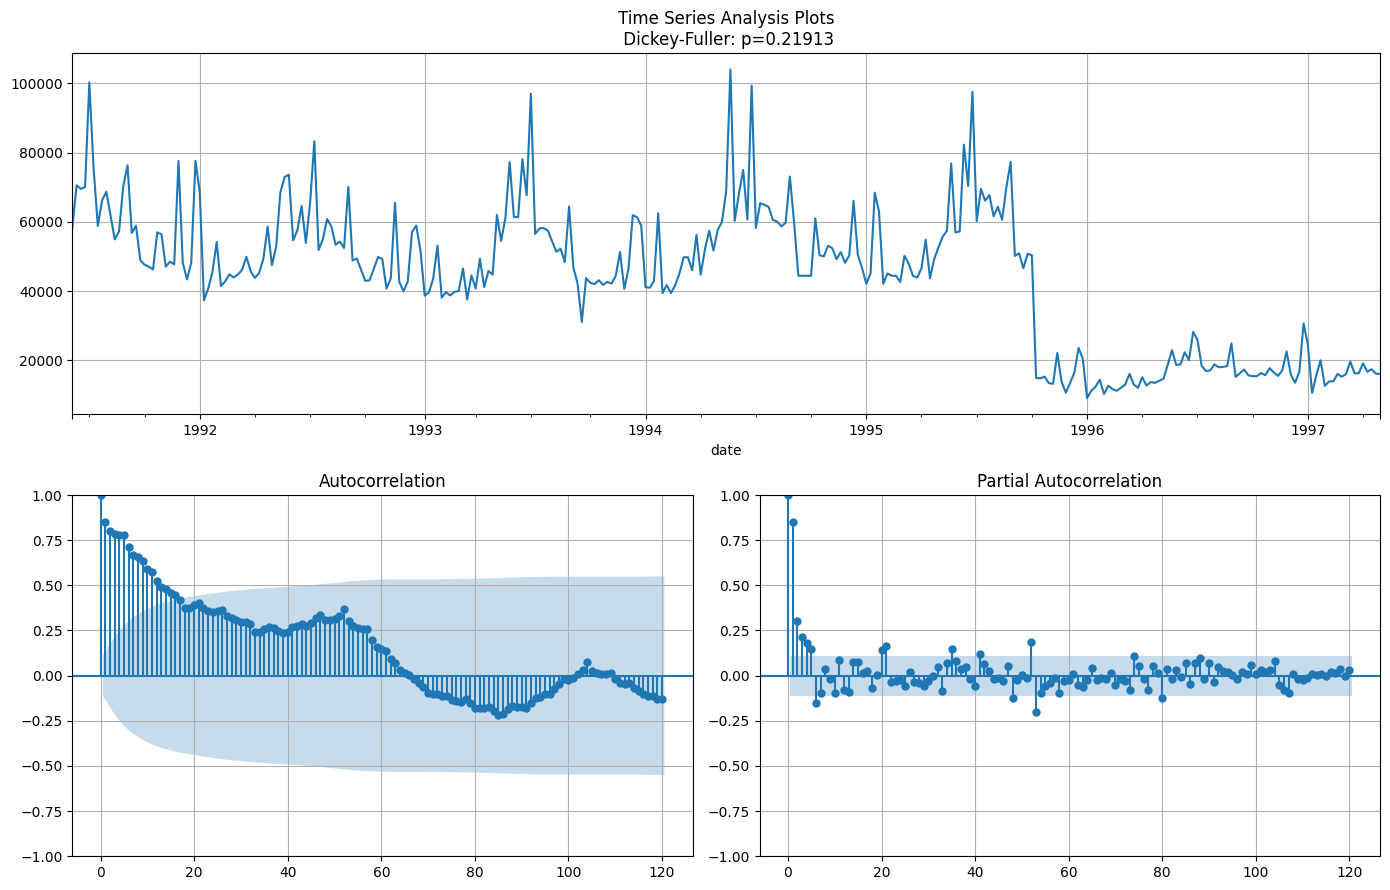

In [379]:
amount0 = indexed_df['move']
tsplot(amount0, 120)

Видим, что ряд нестационарен, так как коэффициент Дики-Фуллера > 0.05

Приведем ряд к стационарному, используя сдвиги:

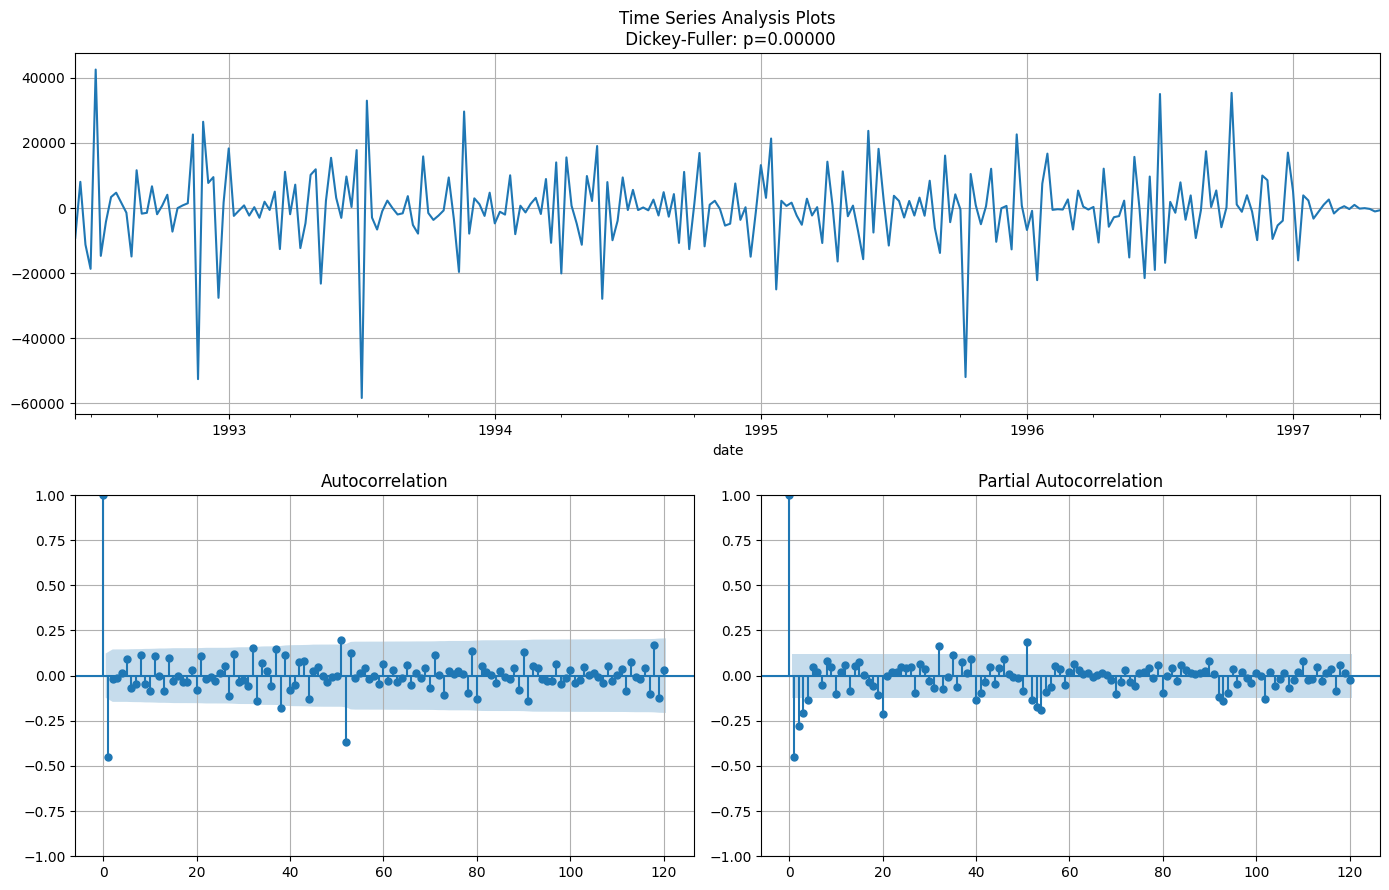

In [380]:
amount1 = (amount0 - amount0.shift(52)).dropna() # Избавляемся от сезонности
amount2 = (amount1 - amount1.shift(1)).dropna()  # Избавляемся от краткосрочных колебаний
tsplot(amount2, 120)

Исходя из графиков автокорреляции имеем параметры для SARIMA:

- p = 2
- d = 1
- q = 1
- P = 1
- D = 1
- Q = 1
- s = 52

In [381]:
# Задаем параметры модели вручную (я заменила на параметры из auto_arima)
p, d, q = 1, 1, 1
P, D, Q, s = 2, 0, 0, 52

In [382]:
"""

# Автоматический подбор параметров SARIMA
arima_model = auto_arima(indexed_df['move'], seasonal=True,
                   m=forecast_periods, stepwise=True, trace=True)

# Извлекаем параметры
p = arima_model.order[0]
d = arima_model.order[1]
q = arima_model.order[2]

P = arima_model.seasonal_order[0]
D = arima_model.seasonal_order[1]
Q = arima_model.seasonal_order[2]
s = arima_model.seasonal_order[3]

# Вывод лучшего результата
print(arima_model.summary())

"""

"\n\n# Автоматический подбор параметров SARIMA\narima_model = auto_arima(indexed_df['move'], seasonal=True,\n                   m=forecast_periods, stepwise=True, trace=True)\n\n# Извлекаем параметры\np = arima_model.order[0]\nd = arima_model.order[1]\nq = arima_model.order[2]\n\nP = arima_model.seasonal_order[0]\nD = arima_model.seasonal_order[1]\nQ = arima_model.seasonal_order[2]\ns = arima_model.seasonal_order[3]\n\n# Вывод лучшего результата\nprint(arima_model.summary())\n\n"

Обучим модель SARIMAX

In [383]:
# Определение модели SARIMAX
sarimax_model = SARIMAX(indexed_df['move'],
                      exog=indexed_df.drop(columns=['move']),
                      order=(p, d, q),
                      seasonal_order=(P, D, Q, s))

# Обучение модели
sarimax_results = sarimax_model.fit()

Визуализируем результат обучения и предсказание на год вперед

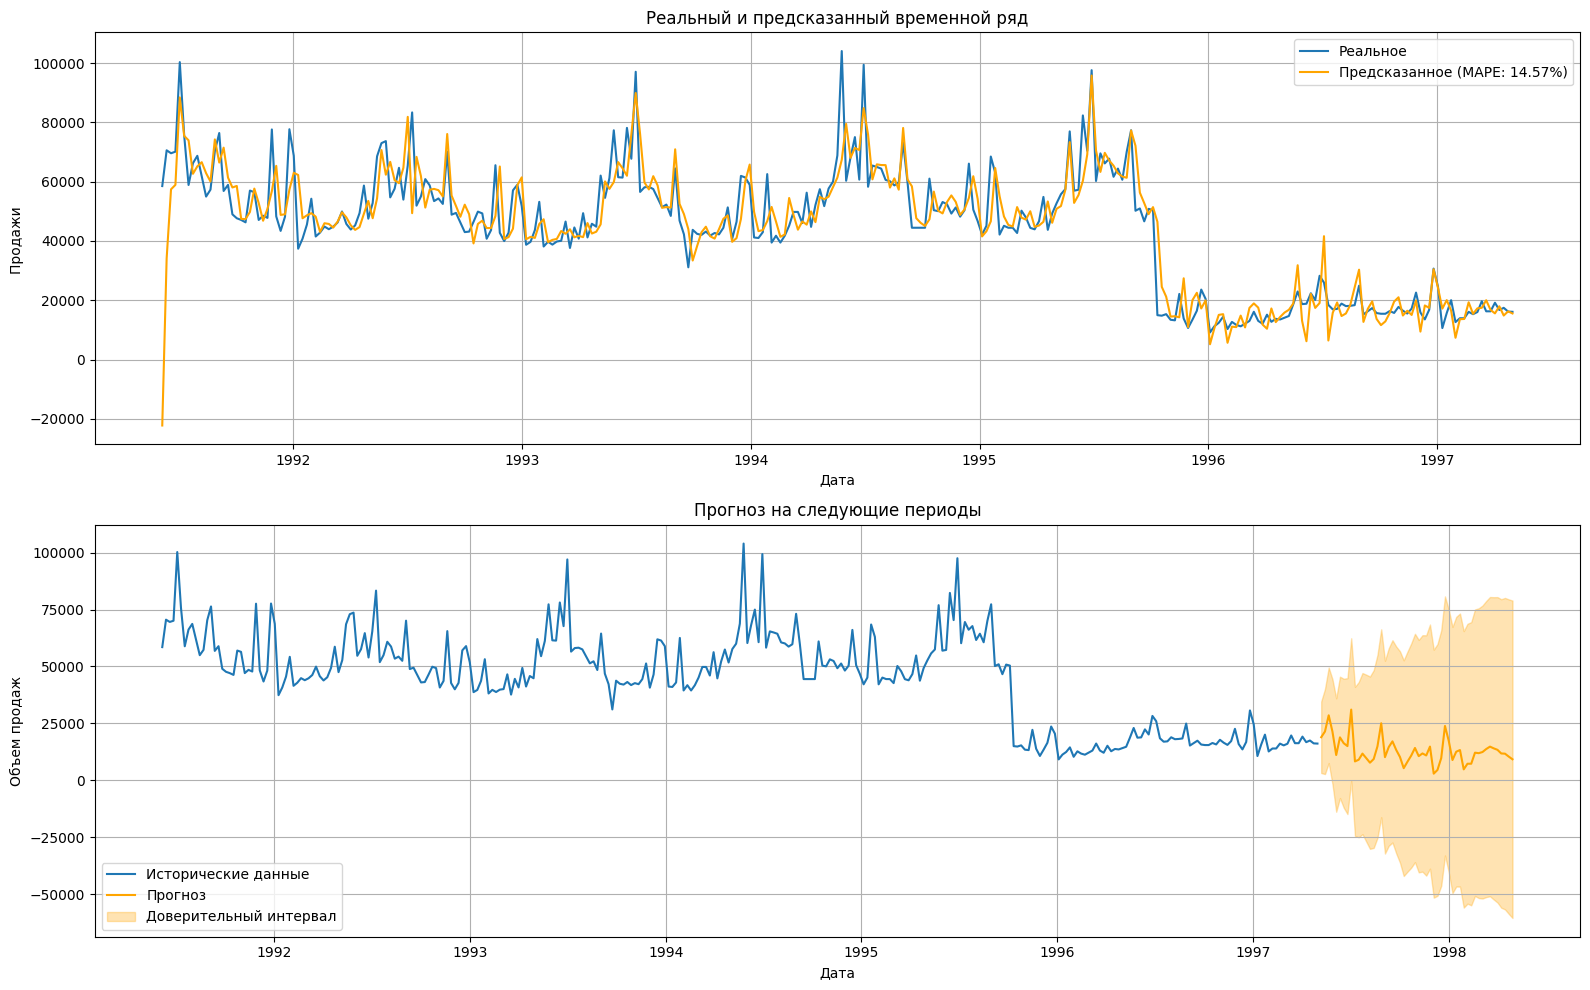

In [384]:
show_results(indexed_df, sarimax_results, exog=exog, forecast_periods=52, is_ts_model=True)

# Модели, не предназначенные для прогнозирования временных рядов

Создадим функцию для добавления дополнительных столбцов с задержанными значениями, так как следующие модели не предназначены для работы с временными рядами

In [385]:
def create_lagged_df(df):
    """
    Создание датафрейма с задержками и их нормализацией.

    Parameters:
    df (DataFrame): Исходный датафрейм.

    Returns:
    DataFrame: Датафрейм с добавленными задержками и их нормализацией.
    """
    # Создание нового датафрейма
    lagged_df = df.drop(columns=['date']).copy()

    # Для столбца move добавляем задержки
    vals = list(range(1, 11)) + list(range(49, 54))
    for i in vals:
        lagged_df[f"lag_{i}"] = lagged_df['move'].shift(i)

    # Нормализация лагов
    scaler = MinMaxScaler()
    lag_columns = [f'lag_{i}' for i in vals]
    lagged_df[lag_columns] = scaler.fit_transform(lagged_df[lag_columns])

    return lagged_df

Добавим новую фиктивную переменную для определения структурного сдвига, с которым модель линейной регрессии и градиентного бустинга не умеют работать, а также добавим лаги

In [396]:
# Добавляем новую фиктивную переменную для определения структурного сдвига
shift_df = df.copy()
shift_df['structural_shift'] = (shift_df['date'] > '1995-10-05').astype(int)

# Создаем датафрейм с лагами и сдвигом
lagged_shift_df = create_lagged_df(shift_df)

Создаем данные для прогноза

In [423]:
# Задаем exog для прогнозирования
exog = lagged_shift_df.drop(columns=['move']).tail(forecast_periods)

# Вывод
tabulate_df(exog.head())

+-----+----------+----------+-----------------+-----------------+-----------------+---------------------+------------------+---------------------+---------------------+------------------------+--------------------+--------------------+--------------------------+------------------------+--------------------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+----------+----------+----------+----------+----------+
|     |    price |     sale | season_Spring   | season_Summer   | season_Winter   | holiday_Christmas   | holiday_Easter   | holiday_Halloween   | holiday_Labor Day   | holiday_Memorial Day   | holiday_New Year   | holiday_Ordinary   | holiday_Presidents Day   | holiday_Thanksgiving   |   structural_shift |     lag_1 |     lag_2 |     lag_3 |     lag_4 |     lag_5 |     lag_6 |     lag_7 |     lag_8 |     lag_9 |    lag_10 |   lag_49 |   lag_50 |   lag_51 |   lag_52 |   lag_53 |
|-----+----------+----------+---

Разделим столбцы на признаки и целевую переменную

In [388]:
# Разделение признаков и целевой переменной
X = lagged_shift_df.drop(columns=['move']).dropna()
y = lagged_shift_df['move'][X.index]

# Разделение данных на обучающий и тестовый наборы последовательно
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Linear Regression

Обучим модель линейной регрессии

In [389]:
# Определение модели линейной регрессии
lr_model = LinearRegression(fit_intercept=True)

# Обучение модели
lr_results = lr_model.fit(X_train, y_train)

Визуализируем результат обучения и предсказание на год вперед

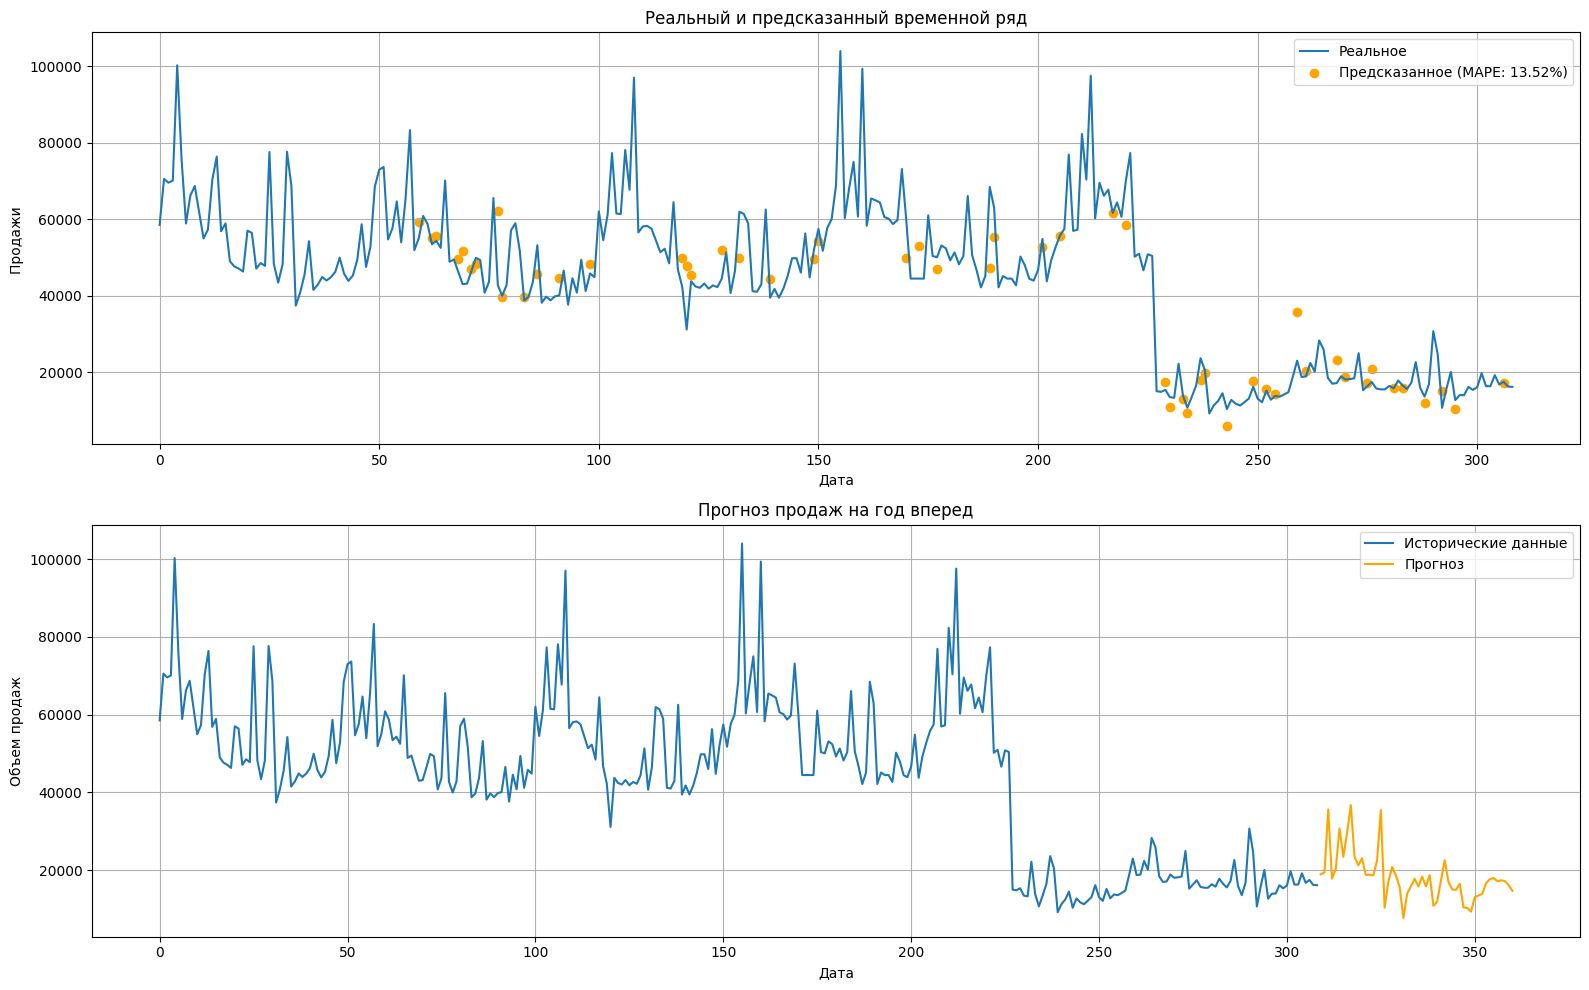

In [401]:
show_results(lagged_shift_df, lr_results, exog=exog, X_test=X_test, y_test=y_test)

## Gradient Boosting

Обучим модель градиентного бустинга

In [391]:
# Определение модели бустинга
gbm_model = GradientBoostingRegressor(n_estimators=100, max_depth=6, random_state=42)

# Обучение модели
gbm_results = gbm_model.fit(X_train, y_train)

Визуализируем результат обучения и предсказание на год вперед

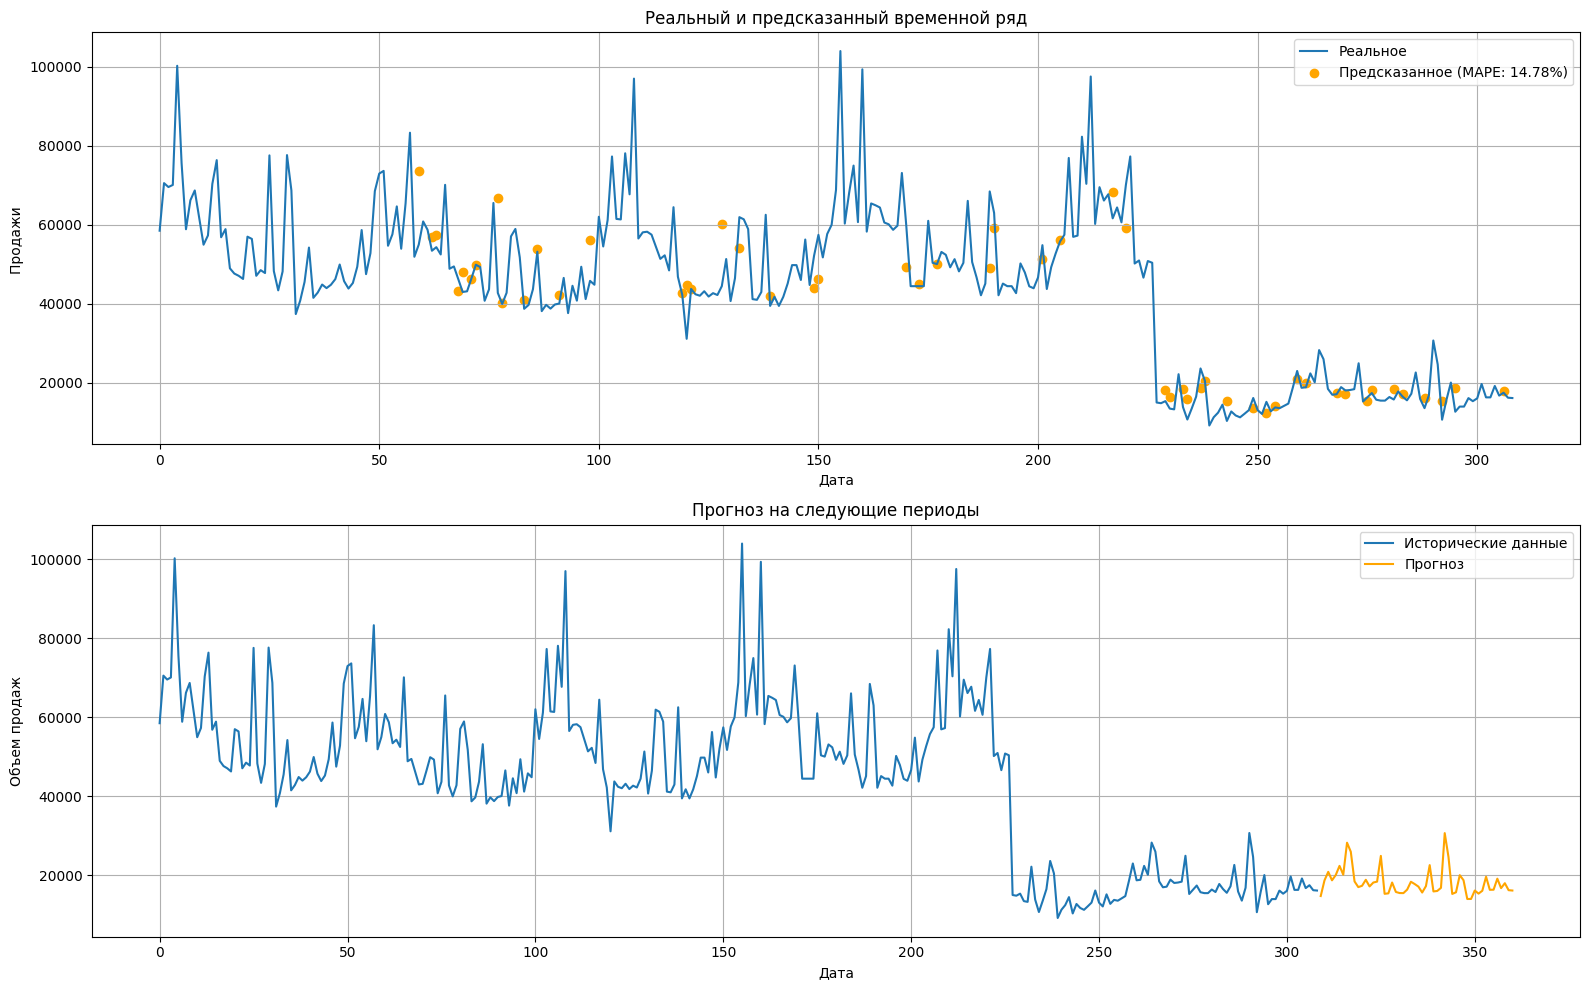

In [392]:
show_results(lagged_shift_df, gbm_results, exog=exog, X_test=X_test, y_test=y_test)

## Decision Tree

Обучим модель дерева решений

In [393]:
# Определение модели дерева решений
tree_model = DecisionTreeRegressor(max_depth=7, random_state=42)

# Обучение модели
tree_results = tree_model.fit(X_train, y_train)

Визуализируем результат обучения и предсказание на год вперед

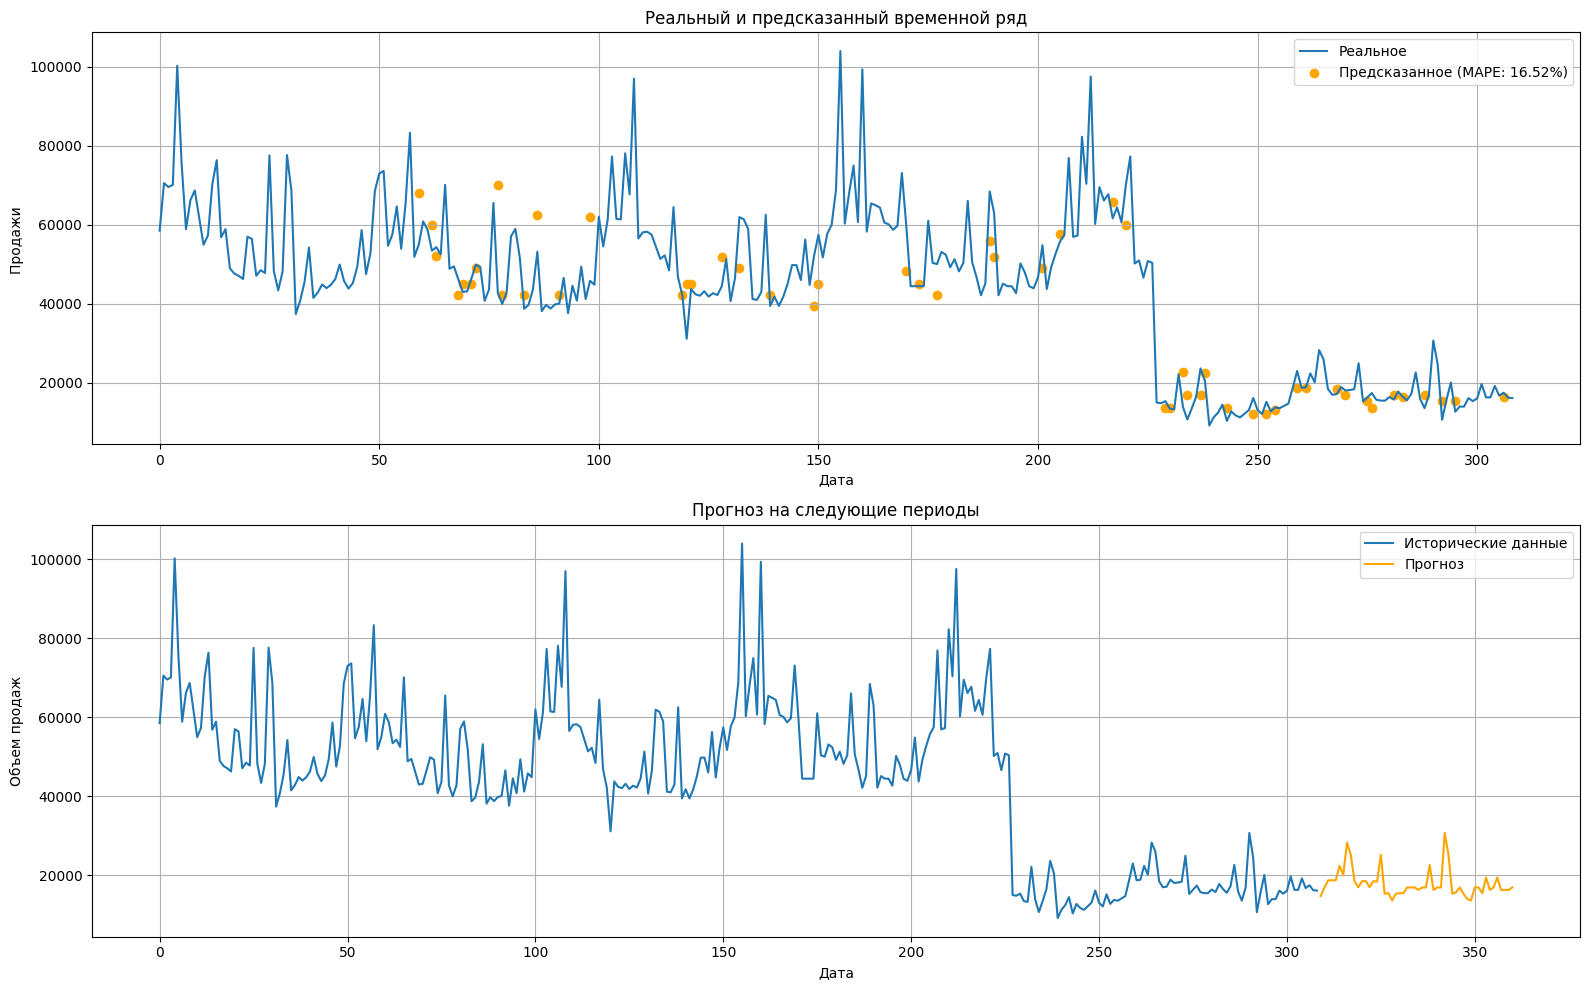

In [394]:
show_results(lagged_shift_df, tree_results, exog=exog, X_test=X_test, y_test=y_test)